# Climate Indicators SSPs Scenarios

<font size ='3'> Climate indices here computed using the **xclim library**.</font>

<font size ='3'> For detailed information, the reader is refered to the xclim official documnetation</font>

<font size ='3'> https://xclim.readthedocs.io/en/stable/indicators.html</font>


In [1]:
from glob import glob
from pathlib import Path
from os.path import basename
import zipfile
import matplotlib.pyplot as plt

#Librairies for working with multi-dimensional arrays
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr #Opening netcdf files as datasets and dataArrays
import pandas as pd
import os

In [2]:
#Libraries for working with climate data
#Projecting the files
import cartopy.crs as ccrs  # projection
import rioxarray
import rasterio

#import xesmf as xe    #For regridding climate data

In [3]:
# Cliping netcdf file

from shapely.geometry import mapping
import geopandas as gpd  #for reading the shapefile
import regionmask  #For masking dataset

In [4]:
#Xclim module
import xclim as xc
from xclim import sdba

from xclim.indices import standardized_precipitation_index

from sklearn.linear_model import LinearRegression # For Linear regression

In [5]:
import xclim.indices
from xclim import testing

In [6]:
#Libray  suite of correlation-based and distance-based deterministic metrics:
import xskillscore as xs
from scipy import stats
import pymannkendall as mk  # For trend analysis

In [7]:
from scipy.stats import norm, kstest
from scipy.stats import ks_2samp

In [8]:
def pearson_correlation(ref, bc):
    R= xs.pearson_r(ref, bc, dim='time', skipna=True, keep_attrs=True)
   
    #converting to array
    r_arr= np.array(R)
    r= np.nanmean(r_arr)
    return r

def variance(ref):
    var= ref.var(skipna=True)
    #converting to array
    var_arr= np.nanmean(var)
    return var_arr


## Statistical tests 
1. <font size ='3'> Student T test</font>
2. <font size ='3'>  F-test </font>
3. <font size ='3'> KS Test</font>

In [9]:
def T_test(sim, ref): # for T test
    statres, pvalue = stats.ttest_rel(ref, sim, nan_policy='omit' )
    p = np.nanmean(pvalue)
    return p

def F_test(sim, ref): # For Fishers f test
    f_value = variance(ref)/variance(sim)
    # Computing the degree of freedom
    df_ref= len(ref)-1
    df_sim= len(sim)-1
    
    #Calculating p value
    p_value = stats.f.cdf(f_value, df_ref,df_sim)
    return p_value


def KS_test(obs, sim):
    ks_statistic, p_value = ks_2samp(obs,sim)
 
    print(f"Kolmogorov–Smirnov Statistic: {ks_statistic}")
    print(f"P-value: {p_value}")

    alpha = 0.05
    if p_value < alpha:
        print("Reject the null hypothesis. The two samples come from different distributions.")
    else:
        print("Fail to reject the null hypothesis. There is not enough evidence to suggest different distributions.")

### Aggregating

In [11]:
def spatial_agg(cm):
    weights = np.cos(np.deg2rad(cm.lat))
    weights.name= 'weights'
    cm_weighted= cm.weighted(weights)
    cm_agg = cm_weighted.mean(['lat','lon'])
    return cm_agg

<Axes: >

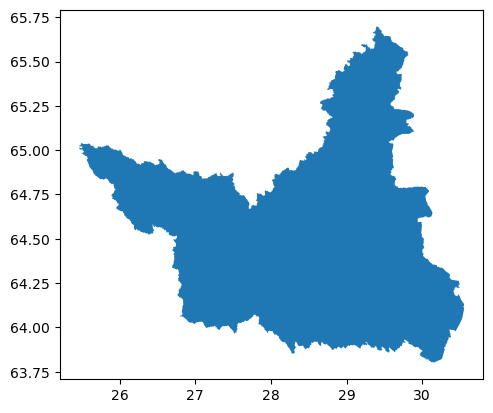

In [12]:
#Reading oulu shapefile
# Reading the shape file
shapefile2 = r"C:\Christine\DEM\ArcMAP\Oulujoki_cat.shp"
shp_oul2= gpd.read_file(shapefile2)  # reading shapefile with geopandas

# from polar coordinates to degrees lon and lat
shp_oul= shp_oul2.to_crs("EPSG: 4326")
shp_oul.plot()

# Temperature Climate Indicators

In [11]:
#Observed

In [ ]:
cm_obs_pr= xr.open_dataset(r"C:\Christine\Hydrology\Downscale\Oulujoki\Pr\Obs_pr_Oul.nc")
cm_obs_tas= xr.open_dataset(r"C:\Christine\Hydrology\Downscale\Oulujoki\Tas_day\Obs_tasday_Oul.nc")

In [ ]:
#Daily minimum temperature
cm_obs_tas= xr.open_dataset(r"D:\Oulujoki\obs_tasmin_oul.nc")

#renaming to tas ( because i dont have the time to update all the variable )

cm_obs_tas = cm_obs_tas.rename({'tasmin':'tas'})
cm_obs_tas

In [ ]:
#Daily minimum temperature
cm_obs_tas= xr.open_dataset(r"D:\Oulujoki\obs_tasmin_oul.nc")

#renaming to tas ( because i dont have the time to update all the variable )

cm_obs_tas = cm_obs_tas.rename({'tasmin':'tas'})
cm_obs_tas

In [ ]:
#Working on units
ds_pr['pr'].attrs['units']= "mm/day"
ds_tas['tas'].attrs['units']= 'degC'

### Definitions

1. <font size ='3'>**Spring Start**</font>
    Day of the year when the threshold temperature of 0 degC is exceeded for 
    atleast 6 days after Ist of January


2. <font size ='3'>**Cold spell days**</font>
    Annual number of days that are part of a cold spell. a cold spell is defined as 5 or more consecutive days with mean daily 
    temperature below -10.0 degc.
    
3. <font size ='3'>**Cold spell Maximum length**</font>
    The maximum annual number of consecutive days in a cold period of 5 day(s) or more, during which the temperature within windows of 5 day(s) is under -10.0 degc.
    
    
4. <font size ='3'>**Number of wet days** </font>
    Days with threshold precipitation of 1.0mm/ day or more

In [12]:
#Preprocessing
#Converting a calendar to read no leap year calendar
def calendar(ds):
    ds = xclim.core.calendar.convert_calendar(ds,'noleap')
    return ds


# Spring Start
def spring_start(dr): # tas mean
    spring_start = xclim.indicators.atmos.freshet_start(tas=dr, thresh='0 degC', 
                                                        op='>',after_date='01-01', window=6, freq='YS')
    return spring_start

def growing_days(dr):
    gdd = xclim.atmos.growing_degree_days(tas=dr, thresh="10.0 degC", freq="YS")
    return gdd


def cold_spell_days(dr):
    cold_spell_days = xclim.atmos.cold_spell_days(tas=dr, thresh="-10.0 degC",window=6, freq="AS-SEP", op='<',
                                              resample_before_rl=True)
    return cold_spell_days



    
def cold_spell_max(dr):
    cold_spell_max_length = xclim.atmos.cold_spell_max_length(tas=dr, thresh="-10.0 degC",window=6, freq="AS-SEP", op='<',
                                              resample_before_rl=True)

    return cold_spell_max_length


def cold_spell_duration_index(dr,tas_10):
    
    #tas_10= xclim.sdba.properties.quantile(dr, q= 0.1, group='time.dayofyear') # First percentile
    CSDI = xclim.indicators.atmos.cold_spell_duration_index(tasmin=dr, tasmin_per=tas_10, window=6, freq="AS-SEP",
                                                            op='<', resample_before_rl=True)
    return CSDI


def frost_days(dr): # tasmin
    frost_days = xclim.indicators.atmos.frost_days(tasmin=dr, thresh="0.0 degC", freq="AS-SEP")
    return frost_days


def consecutive_frost_days(dr): # tasmin
    CFD = xclim.indicators.atmos.consecutive_frost_days(tasmin=dr, thresh="0.0 degC", freq="AS-SEP",
                                              resample_before_rl=True)
    return CFD


def frost_season(dr): # tasmin  Forst season length
    frost_season= xclim.indicators.atmos.frost_season_length(tasmin=dr, thresh="0.0 degC", window=5, freq="AS-SEP", op='<',
                                              mid_date='01-01')
    return frost_season




def ice_days(dr): # tasmax
    ice_days = xclim.indicators.atmos.ice_days(tasmax=dr, thresh="0.0 degC", freq="AS-SEP")
    return ice_days



    
def wet_days(dr):#By changing the threshold to 10mm and 20mm we get days with heavy and vey heavy precipiation
    wet_days = xclim.atmos.wetdays(dr, thresh='1.0 mm/day', 
                               freq='AS-SEP', op='>=')
    return wet_days

def SDII(dr):
    SDI = xclim.indicators.atmos.daily_pr_intensity(dr, thresh='1.0 mm/day', 
                               freq='AS-SEP', op='>=')
    return SDI


def RR10(dr):#By changing the threshold to 10mm and 20mm we get days with heavy and vey heavy precipiation
    Rx10 = xclim.atmos.wetdays(dr, thresh='10.0 mm/day', 
                               freq='AS-SEP', op='>=')
    return Rx10


def RR20(dr):#By changing the threshold to 10mm and 20mm we get days with heavy and vey heavy precipiation
    Rx20 = xclim.atmos.wetdays(dr, thresh='20.0 mm/day', 
                               freq='AS-SEP', op='>=')
    return Rx20



def wet_day(ds):  
    wet_day= xclim.atmos.daily_pr_intensity(ds, 
                                            thresh='1 mm/day', freq='D', op='>=')
    return wet_day

#Cold and wet days:
def cold_wet_days(dr_tas, dr_pr, wet_day):
    # Percentiles
    #Percentiles

    pr_25= xclim.sdba.properties.quantile(wet_day,q= 0.25, group='time.dayofyear') # First percentile
    pr_75= xclim.sdba.properties.quantile(wet_day,q= 0.75, group='time.dayofyear') # third percentile

    # Temperature

    tas_25= xclim.sdba.properties.quantile(dr_tas, q= 0.25, group='time.dayofyear') # First percentile
    tas_75= xclim.sdba.properties.quantile(dr_tas, q= 0.75, group='time.dayofyear') # third percentile

    cold_wet_days= xclim.atmos.cold_and_wet_days(dr_tas, 
                                             dr_pr, tas_25, pr_75, freq='AS-SEP')
    return cold_wet_days

#Cold and wet days:
def cold_wet_daysic(dr_tas, dr_pr, wet_day):
    # Percentiles
    #Percentiles

    pr_25= xclim.sdba.properties.quantile(wet_day,q= 0.25, group='time.dayofyear') # First percentile
    pr_75= xclim.sdba.properties.quantile(wet_day,q= 0.75, group='time.dayofyear') # third percentile

    # Temperature

    tas_25= xclim.sdba.properties.quantile(dr_tas, q= 0.25, group='time.dayofyear') # First percentile
    tas_75= xclim.sdba.properties.quantile(dr_tas, q= 0.75, group='time.dayofyear') # third percentile

    cold_wet_days= xclim.indicators.icclim.CW(dr_tas, dr_pr, 
                                   tas_25, pr_75, freq='YS')
    return cold_wet_days


#warm and wet days:
def warm_wet_days(dr_tas, dr_pr, wet_day):
    # Percentiles
    #Percentiles

    pr_25= xclim.sdba.properties.quantile(wet_day,q= 0.25, group='time.dayofyear') # First percentile
    pr_75= xclim.sdba.properties.quantile(wet_day,q= 0.75, group='time.dayofyear') # third percentile

    # Temperature

    tas_25= xclim.sdba.properties.quantile(dr_tas, q= 0.25, group='time.dayofyear') # First percentile
    tas_75= xclim.sdba.properties.quantile(dr_tas, q= 0.75, group='time.dayofyear') # third percentile

    warm_wet_days= xclim.atmos.warm_and_wet_days(dr_tas, 
                                             dr_pr, tas_75, pr_75, freq='AS-SEP')
    return warm_wet_days


#Number of days of precipitation above a diven daily percentile

def very_wet_day(wet_day, dr_pr):
    prall_25= wet_day.quantile(0.25, dim='time', keep_attrs=True)   # First percentile
    prall_95= wet_day.quantile(0.95, dim='time',keep_attrs=True)
    
    over_95= xclim.atmos.days_over_precip_thresh(dr_pr, prall_95, 
                                            thresh='1mm/day',freq='AS-SEP',
                                           bootstrap=False, op='>')
    return over_95



def SPI_3(hist_pr, pr):
    pr_cal= hist_pr.sel(time=slice(None, '2009-12-31'))
    spi_3 = standardized_precipitation_index(pr, pr_cal, freq="MS", window=12, 
                                             dist="gamma", method="ML")  # Computing SPI-3 months using a gamma distribution 
    return spi_3


def consecutive_dry_days(dr_pr):
    cdd = xclim.indicators.atmos.maximum_consecutive_dry_days(pr=dr_pr, thresh='1 mm/day',
                                                              freq='AS-SEP', resample_before_rl=True)
    return cdd


def consecutive_wet_days(dr_pr):
    cwd = xclim.indicators.atmos.maximum_consecutive_wet_days(pr=dr_pr, thresh='1 mm/day',
                                                              freq='AS-SEP', resample_before_rl=True)
    return cwd


def RX1day(dr_pr):  # One Day Maximum Precipiation
    Rx1_day = xclim.indicators.icclim.RX1day(pr= dr_pr, freq='AS-SEP')
    return Rx1_day


def RX5day(dr_pr):
    Rx5_day = xclim.indicators.icclim.RX5day(pr= dr_pr, freq='AS-SEP')
    return Rx5_day

def R99p(wet_day, dr_pr, R99):
    #prall_25= wet_day.quantile(0.25, dim='time', keep_attrs=True)   # First percentile
    #prall_99= wet_day.quantile(0.99, dim='time',keep_attrs=True)
    
    over_99= xclim.atmos.days_over_precip_thresh(dr_pr, R99, 
                                            thresh='1mm/day',freq='AS-SEP',
                                           bootstrap=False, op='>')
    return over_99


def R95p(wet_day, dr_pr, R95):
    #prall_25= wet_day.quantile(0.25, dim='time', keep_attrs=True)   # First percentile
    #prall_99= wet_day.quantile(0.99, dim='time',keep_attrs=True)
    
    over_95= xclim.atmos.days_over_precip_thresh(dr_pr, R95, 
                                            thresh='1mm/day',freq='AS-SEP',
                                           bootstrap=False, op='>')
    return over_95


def liq_prec_ratio(dr_pr, dr_tas):
    liq_prec_ratio = xclim.indicators.atmos._precip.liquid_precip_ratio(pr=dr_pr, tas=dr_tas, 
                                              thresh='0 degC',freq='AS-SEP')
    return liq_prec_ratio

    
def prcptot(dr_pr):
    prcptot = xclim.indicators.atmos.wet_precip_accumulation(pr= dr_pr, thresh='1 mm/day', freq='AS-SEP')
    
    return prcptot


def snow_fall_approx(dr_pr, dr_tas):
    snow_fall_approx= xclim.atmos.snowfall_approximation(pr=dr_pr, tas=dr_tas, 
                                              thresh='0 degC', method='binary')
    
    return snow_fall_approx

def snow_days(dr_snow):
    snow_days=xclim.atmos.days_with_snow(dr_snow, low='0 kg m-2 s-1',
                                         high='1E6 kg m-2 s-1', freq='AS-SEP')
    return snow_days
    
def dataframe(ds):
    df = ds.to_dataframe()
    df.index= df.index.to_datetimeindex()
    return df


In [ ]:
#Tas mean

#GCM projection 
#Daily mean precipitation
data_tas= xr.open_dataset(path)

data_tas= calendar(data_tas)
data_tas

In [ ]:
#Tas min

data_tas= xr.open_dataset(path)

data_tas = data_tas.rename({'tasmin':'tas'})

data_tas= calendar(data_tas)
data_tas

In [ ]:
#tas max
data_tas= xr.open_dataset(r"D:\Oulujoki\BC\Tasmax\ens_oul_tasmax.nc")
data_tas = data_tas.rename({'tasmax':'tas'})

#Changing calendar
data_tas= calendar(data_tas)
data_tas

In [ ]:
cm_obs_tas = calendar(cm_obs_tas)
cm_obs_tas

In [25]:
hist_tas2 = data_tas['tas'][0].sel(time=slice(None, '2014-12-31')) #GCM historical
hist_tas = cm_obs_tas['tas'].sel(time=slice(None, '2014-12-31')) #Observed
obs = hist_tas.copy()

In [27]:
sim = hist_tas2.copy()
#sim= sim.reset_coords(names={"experiment","quantile","spatial_ref"}, drop=True)
sim= sim.reset_coords(names={"experiment"}, drop=True)

sim= sim.transpose('time','lat','lon')

In [ ]:
#comparing the statistical significancy of bias corrected historical precipitation
statres, pvalue = stats.ttest_rel(sim, obs)
np.nanmean(pvalue)

In [ ]:
hist_tas2_m = sim.resample(time='M').mean(dim='time', skipna=False)
hist_tas_m= obs.resample(time='M').mean(dim='time', skipna=False)

### Statistical Tests on historical simulation against Observation

In [ ]:
#comparing the statistical significancy of bias corrected historical temperature
statres, pvalue = stats.ttest_rel(hist_tas2_m, hist_tas_m)
np.nanmean(pvalue)

In [ ]:
print(f'The cofficient of correlation between model and observed is {pearson_correlation(obs,sim)}')
print(f'The p_value between model and observed {T_test(sim, obs)}')
print(f'The p_value for Fishers f-test betwen ensemble and observed is {F_test(sim, obs)}')

In [29]:
print(f'The cofficient of correlation between model and observed is {pearson_correlation(hist_tas2_m,hist_tas_m)}')
print(f'The p_value between model and observed {T_test(hist_tas2_m, hist_tas_m)}')
print(f'The p_value for Fishers f-test betwen ensemble and observed is {F_test(hist_tas2_m, hist_tas_m)}')

In [70]:
hist_tas2 = data_tas['tas'][0].sel(time=slice(None, '2014-12-31'))
hist_tas = cm_obs_tas['tas']
ssp126= data_tas['tas'][1].sel(time=slice('2015-01-01',None))

ssp245= data_tas['tas'][2].sel(time=slice('2015-01-01', None))
ssp370= data_tas['tas'][3].sel(time=slice('2015-01-01', None))
ssp585= data_tas['tas'][4].sel(time=slice('2015-01-01', None))

### Here we used a Hydrological year

In [22]:
hist_tas2 = data_tas['tas'][0].sel(time=slice(None,'2014-08-31'))
hist_tas = cm_obs_tas['tas'].sel(time=slice(None, '2022-08-31'))

In [71]:
hist_tas2 = data_tas['tas'][0].sel(time=slice('1980-09-01','2014-08-31' ))
hist_tas = cm_obs_tas['tas'].sel(time=slice('1980-09-01', '2022-08-31'))
ssp126= data_tas['tas'][1].sel(time=slice('2015-09-01', '2100-08-31'))

ssp245= data_tas['tas'][2].sel(time=slice('2015-09-01', '2100-08-31'))
ssp370= data_tas['tas'][3].sel(time=slice('2015-09-01', '2100-08-31'))
ssp585= data_tas['tas'][4].sel(time=slice('2015-09-01', '2100-08-31'))

In [ ]:
#Computing quantiles 
hist_tas_25= xclim.sdba.properties.quantile(hist_tas, q= 0.25, group='time.dayofyear') # First percentile

tas_25= xclim.sdba.properties.quantile(hist_tas, q= 0.25, group='time.dayofyear') # First percentile
tas_75= xclim.sdba.properties.quantile(hist_tas, q= 0.75, group='time.dayofyear') # third percentile

# 1. Cold Climate indices 

## A.1  Frost days

In [ ]:
hist_tas2 = data_tas['tasmin'][0].sel(time=slice(None,'2014-08-31' ))
hist_tas = cm_obs_tas['tasmin'].sel(time=slice('1980-09-01', '2022-08-31'))
ssp126= data_tas['tasmin'][1].sel(time=slice('2015-09-01', '2100-08-31'))

ssp245= data_tas['tasmin'][2].sel(time=slice('2015-09-01', '2100-08-31'))
ssp370= data_tas['tasmin'][3].sel(time=slice('2015-09-01', '2100-08-31'))
ssp585= data_tas['tasmin'][4].sel(time=slice('2015-09-01', '2100-08-31'))

In [ ]:
hist_fd= frost_days(hist_tas)
ssp126_fd= frost_days(ssp126)
ssp245_fd= frost_days(ssp245)
ssp370_fd= frost_days(ssp370)
ssp585_fd= frost_days(ssp585)

## A.2 Consecutive Frost Days

In [ ]:
hist_cfd= consecutive_frost_days(hist_tas)
ssp126_cfd= consecutive_frost_days(ssp126)
ssp245_cfd= consecutive_frost_days(ssp245)
ssp370_cfd= consecutive_frost_days(ssp370)
ssp585_cfd= consecutive_frost_days(ssp585)

## A.3 Frost season

In [ ]:
hist_fs= frost_season(hist_tas2)
hist_fs= frost_season(hist_tas)
ssp126_fs= frost_season(ssp126)
ssp245_fs= frost_season(ssp245)
ssp370_fs= frost_season(ssp370)
ssp585_fs= frost_season(ssp585)

In [378]:
hist_ref =hist_fs.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')


## A.4 Ice days

In [ ]:
hist_id= ice_days(hist_tas)

In [ ]:
hist_id2= ice_days(hist_tas2)
hist_id= ice_days(hist_tas)
ssp126_id= ice_days(ssp126)
ssp245_id= ice_days(ssp245)
ssp370_id= ice_days(ssp370)
ssp585_id= ice_days(ssp585)

In [541]:
hist_ref =hist_id.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## A.5 Cold spell maximum length

In [ ]:
hist_cml= cold_spell_max(obs)
hist_cml2= cold_spell_max(sim)


In [ ]:
statres, pvalue = stats.ttest_rel(hist_cml, hist_cml2, nan_policy='omit')
np.nanmean(pvalue)

In [ ]:
print(f'The cofficient of correlation between model and observed cold spells is {pearson_correlation(hist_cml,hist_cml)}')
print(f'The p_value between model and observed cold spells {T_test(hist_cml,hist_cml2)}')
print(f'The p_value for Fishers f-test betwen ensemble and observed is {F_test(hist_cml,hist_cml)}')

In [ ]:
hist_cml= cold_spell_max(hist_tas)
ssp126_cml= cold_spell_max(ssp126)
ssp245_cml= cold_spell_max(ssp245)
ssp370_cml= cold_spell_max(ssp370)
ssp585_cml= cold_spell_max(ssp585)

## A.6 Cold Spell day

In [ ]:
hist_csd= cold_spell_days(obs)
hist_csd= cold_spell_days(sim)

In [ ]:
print(f'The cofficient of correlation between model and observed cold spells is {pearson_correlation(hist_csd,hist_csd2)}')
print(f'The p_value between model and observed cold spells {T_test(hist_csd,hist_csd2)}')
print(f'The p_value for Fishers f-test betwen ensemble and observed is {F_test(hist_csd,hist_csd2)}')

In [ ]:

hist_csd= cold_spell_days(hist_tas)
ssp126_csd= cold_spell_days(ssp126)
ssp245_csd= cold_spell_days(ssp245)
ssp370_csd= cold_spell_days(ssp370)
ssp585_csd= cold_spell_days(ssp585)

## A.7 Cold Spell duration Index

In [ ]:
#tas_10= hist_tas.quantile(0.1, dim='time',keep_attrs=True)

tas_10= xclim.sdba.properties.quantile(hist_tas, q= 0.1, group='time.dayofyear') # First percentile time.dayofyear

In [ ]:
hist_csdi2= cold_spell_duration_index(hist_tas2)
hist_csdi= cold_spell_duration_index(hist_tas)

In [ ]:
#hist_spring2= cold_spell_duration_index(hist_tas2)
hist_csdi= cold_spell_duration_index(hist_tas)
ssp126_csdi= cold_spell_duration_index(ssp126)
ssp245_csdi= cold_spell_duration_index(ssp245)
ssp370_csdi= cold_spell_duration_index(ssp370)
ssp585_csdi= cold_spell_duration_index(ssp585)

In [83]:
hist_ref =hist_csdi.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## A.8 Spring start day

In [ ]:
 #historical performance
hist_spring= spring_start(obs)
hist_spring2= spring_start(sim)


## A. 10 Spring Freshet

In [ ]:
hist_spring2= spring_start(hist_tas2)
hist_spring= spring_start(hist_tas)
ssp126_spring= spring_start(ssp126)
ssp245_spring= spring_start(ssp245)
ssp370_spring= spring_start(ssp370)
ssp585_spring= spring_start(ssp585)

In [489]:
hist_ref =hist_spring.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')
#hist_ref_mean

# B Precipitation Indices

In [17]:
DATADIR= path_to_files

In [ ]:
data_pr= xr.open_dataset(path) # Climate projection file for Daily precipitation with all SSP scenarios

#Working on units
data_pr['pr'].attrs['units']= "mm/day"
data_pr= calendar(data_pr)


cm_obs_pr['pr'].attrs['units']= "mm/day"
cm_obs_pr= calendar(cm_obs_pr)

In [21]:
#Slicing for the same time period
hist_pr2 = data_pr['pr'][0].sel(time=slice(None, '2014-12-31')) # historical simulation
hist_pr = cm_obs_pr['pr'].sel(time = slice(None, '2014-12-31')) # Observed data

In [18]:
obs_pr = hist_pr.copy()
sim_pr = hist_pr2.copy()
#sim_pr=sim_pr .reset_coords(names={"experiment","quantile","spatial_ref"}, drop=True)
sim_pr=sim_pr .reset_coords(names={"experiment"}, drop=True)
sim_pr = sim_pr.transpose('time','lat','lon')


In [16]:
#hist_pr = data_pr['pr'][0].sel(time=slice(None, '2014-12-31'))
ssp126_pr= data_pr['pr'][1].sel(time=slice('2015-01-01',None))

ssp245_pr= data_pr['pr'][2].sel(time=slice('2015-01-01', None))
ssp370_pr= data_pr['pr'][3].sel(time=slice('2015-01-01', None))
ssp585_pr= data_pr['pr'][4].sel(time=slice('2015-01-01', None))

### Based on a hydrological year

In [44]:
hist_pr2 = data_pr['pr'][0].sel(time=slice(None, '2014-08-31'))
hist_pr = cm_obs_pr['pr'].sel(time = slice(None, '2014-08-31'))

In [22]:
sim_pr = data_pr['pr'][0].sel(time=slice('1980-09-01', '2014-08-31'))
hist_pr = cm_obs_pr['pr'].sel(time = slice('1980-09-01', '2022-08-31'))
ssp126_pr= data_pr['pr'][1].sel(time=slice('2015-09-01', '2100-08-31'))

ssp245_pr= data_pr['pr'][2].sel(time=slice('2015-09-01', '2100-08-31'))
ssp370_pr= data_pr['pr'][3].sel(time=slice('2015-09-01', '2100-08-31'))
ssp585_pr= data_pr['pr'][4].sel(time=slice('2015-09-01', '2100-08-31'))

## B.1 Wet day

In [ ]:
hist_wetday= wet_day(obs_pr)
hist_wetday2= wet_day(sim_pr)

In [ ]:
prall_95_obs= hist_wetday.quantile(0.95, dim='time',keep_attrs=True)
prall_95_sim= hist_wetday2.quantile(0.95, dim='time',keep_attrs=True)

#### Checking for the significance of the GCM simulation 

In [ ]:
print(f'The cofficient of correlation between model and observed wet days is {pearson_correlation(hist_wetday2, hist_wetday)}')
print(f'The p_value between model and observed wetdays  {T_test(hist_wetday2, hist_wetday)}')
print(f'The p_value for Fishers f-test betwen ensemble and observed is {F_test(hist_wetday2, hist_wetday)}')

## B.2 R99p 

In [ ]:
#a  Wet day
#hist_wetday2= wet_day(sim_pr)
hist_wetday= wet_day(hist_pr)
ssp126_wetday= wet_day(ssp126_pr)
ssp245_wetday= wet_day(ssp245_pr)
ssp370_wetday= wet_day(ssp370_pr)
ssp585_wetday= wet_day(ssp585_pr)

In [ ]:
R99p_hist= hist_wetday.quantile(0.99, dim='time',keep_attrs=True)
#R99p_hist2= hist_wetday2.quantile(0.99, dim='time',keep_attrs=True)

In [ ]:
#hist_wetdays2= R99p(hist_wetday2,sim_pr,R99p_hist2)

hist_99p= R99p(hist_wetday,hist_pr,R99p_hist)
ssp126_99p= R99p(ssp126_wetday,ssp126_pr,R99p_hist)
ssp245_99p= R99p(ssp245_wetday,ssp245_pr,R99p_hist)
ssp370_99p= R99p(ssp370_wetday,ssp370_pr,R99p_hist)
ssp585_99p= R99p(ssp585_wetday,ssp585_pr,R99p_hist)

In [197]:
#Computing reference mean
hist_ref =hist_99p.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.3 R95p

In [ ]:
R95p_hist= hist_wetday.quantile(0.95, dim='time',keep_attrs=True)
#R95p_hist2= hist_wetday2.quantile(0.95, dim='time',keep_attrs=True)

In [ ]:
#hist_95p2= R95p(hist_wetday2,sim_pr,R95p_hist2)

hist_95p= R95p(hist_wetday,hist_pr,R95p_hist)
ssp126_95p= R95p(ssp126_wetday,ssp126_pr,R95p_hist)
ssp245_95p= R95p(ssp245_wetday,ssp245_pr,R95p_hist)
ssp370_95p= R95p(ssp370_wetday,ssp370_pr,R95p_hist)
ssp585_95p= R95p(ssp585_wetday,ssp585_pr,R95p_hist)

In [205]:
#Computing reference mean
hist_ref =hist_95p.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.4 Very wet days

In [ ]:
hist_wetdays= very_wet_day(hist_wetday,hist_pr)
ssp126_wetdays= very_wet_day(ssp126_wetday,ssp126_pr)
ssp245_wetdays= very_wet_day(ssp245_wetday,ssp245_pr)
ssp370_wetdays= very_wet_day(ssp370_wetday,ssp370_pr)
ssp585_wetdays= very_wet_day(ssp585_wetday,ssp585_pr)

## B.5 Wet days

In [ ]:
#Checking for significance of wet days simulation in GCMs
print(f'The cofficient of correlation between model and observed wet days is {pearson_correlation(hist_wetdays2, hist_wetdays)}')
print(f'The p_value between model and observed wetdays  {T_test(hist_wetdays2, hist_wetdays)}')
print(f'The p_value for Fishers f-test betwen ensemble and observed is {F_test(hist_wetdays2, hist_wetdays)}')

In [ ]:
#hist_wetdays2= wet_days(sim_pr)
hist_wetdays= wet_days(hist_pr)
ssp126_wetdays= wet_days(ssp126_pr)
ssp245_wetdays= wet_days(ssp245_pr)
ssp370_wetdays= wet_days(ssp370_pr)
ssp585_wetdays= wet_days(ssp585_pr)

In [209]:
#Computing reference mean
hist_ref =hist_wetdays.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.5 R10mm

In [ ]:
#hist_R10mm2= RR10(sim_pr)
hist_R10mm= RR10(hist_pr)
ssp126_R10mm= RR10(ssp126_pr)
ssp245_R10mm= RR10(ssp245_pr)
ssp370_R10mm= RR10(ssp370_pr)
ssp585_R10mm= RR10(ssp585_pr)

In [24]:
#Computing reference mean
hist_ref =hist_R10mm.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.6 R20mm

In [ ]:
#hist_R20mm2= RR20(sim_pr)
hist_R20mm= RR20(hist_pr)
ssp126_R20mm= RR20(ssp126_pr)
ssp245_R20mm=RR20(ssp245_pr)
ssp370_R20mm= RR20(ssp370_pr)
ssp585_R20mm= RR20(ssp585_pr)

In [28]:
#Computing reference mean
hist_ref =hist_R20mm.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.7 Cold and Wet days

In [ ]:
hist_cwetdays= cold_wet_daysic(hist_tas, hist_pr, hist_wetday)
ssp126_cwetdays= cold_wet_daysic(ssp126, ssp126_pr, ssp126_wetday)
ssp245_cwetdays= cold_wet_daysic(ssp245, ssp245_pr, ssp245_wetday)
ssp370_cwetdays= cold_wet_daysic(ssp370, ssp370_pr, ssp370_wetday)
ssp585_cwetdays= cold_wet_daysic(ssp585, ssp585_pr, ssp585_wetday)

## B.8 Warm and wet days

In [ ]:
hist_wwetdays= warm_wet_days(hist_tas, hist_pr, hist_wetday)
ssp126_wwetdays= warm_wet_days(ssp126, ssp126_pr, ssp126_wetday)
ssp245_wwetdays= warm_wet_days(ssp245, ssp245_pr, ssp245_wetday)
ssp370_wwetdays= warm_wet_days(ssp370, ssp370_pr, ssp370_wetday)
ssp585_wwetdays= warm_wet_days(ssp585, ssp585_pr, ssp585_wetday)

## B.9 Consecutive Dry Days

In [ ]:
hist_cdd= consecutive_dry_days(obs_pr)
hist_cdd2= consecutive_dry_days(sim_pr)

In [ ]:
hist_cdd= consecutive_dry_days(hist_pr)
ssp126_cdd= consecutive_dry_days(ssp126_pr)
ssp245_cdd= consecutive_dry_days(ssp245_pr)
ssp370_cdd= consecutive_dry_days(ssp370_pr)
ssp585_cdd= consecutive_dry_days(ssp585_pr)

## B.10 Consecutive Wet Days

In [ ]:
#hist_cwd2= consecutive_wet_days(sim_pr)
hist_cwd= consecutive_wet_days(hist_pr)
ssp126_cwd= consecutive_wet_days(ssp126_pr)
ssp245_cwd= consecutive_wet_days(ssp245_pr)
ssp370_cwd= consecutive_wet_days(ssp370_pr)
ssp585_cwd= consecutive_wet_days(ssp585_pr)

In [198]:
#Computing reference mean
hist_ref =hist_cwd.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.11 Maximum RX1 day precipitation

In [ ]:
hist_Rx12= RX1day(sim_pr)

hist_Rx1= RX1day(hist_pr)

In [ ]:
#hist_wetdays2= RX1day(sim_pr)

hist_Rx1= RX1day(hist_pr)
ssp126_Rx1= RX1day(ssp126_pr)
ssp245_Rx1= RX1day(ssp245_pr)
ssp370_Rx1= RX1day(ssp370_pr)
ssp585_Rx1= RX1day(ssp585_pr)

In [32]:
#Computing reference mean
hist_ref =hist_Rx1.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.12 Maximum RX5 day precipitation

In [ ]:
hist_rx52= RX5day(sim_pr)
hist_rx5= RX5day(hist_pr)

In [ ]:
#hist_wetdays2= RX5day(sim_pr)
hist_rx5= RX5day(hist_pr)
ssp126_rx5= RX5day(ssp126_pr)
ssp245_rx5= RX5day(ssp245_pr)
ssp370_rx5= RX5day(ssp370_pr)
ssp585_rx5= RX5day(ssp585_pr)

In [42]:
#Computing reference mean
hist_ref =hist_rx5.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.13 Precipitation Total

In [ ]:
#hist_prcptot2= prcptot(sim_pr)
hist_prcptot= prcptot(hist_pr)
ssp126_prcptot= prcptot(ssp126_pr)
ssp245_prcptot= prcptot(ssp245_pr)
ssp370_prcptot= prcptot(ssp370_pr)
ssp585_prcptot= prcptot(ssp585_pr)

In [235]:
hist_ref =hist_wetdays.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.14 Snow fall approximation

In [ ]:
hist_snow= snow_fall_approx(obs_pr, obs)
hist_snow2= snow_fall_approx(sim_pr, sim)

In [ ]:
hist_snow= snow_fall_approx(hist_pr, hist_tas)
ssp126_snow= snow_fall_approx(ssp126_pr, ssp126)
ssp245_snow= snow_fall_approx(ssp245_pr, ssp245)
ssp370_snow= snow_fall_approx(ssp370_pr, ssp370)
ssp585_snow= snow_fall_approx(ssp585_pr, ssp585)


In [ ]:
hist_sd= snow_days(hist_snow)
hist_sd= snow_days(hist_snow2)

In [ ]:
#Snow days
hist_sd= snow_days(hist_snow)
ssp126_sd= snow_days(ssp126_snow)
ssp245_sd= snow_days(ssp245_snow)
ssp370_sd= snow_days(ssp370_snow)
ssp585_sd= snow_days(ssp585_snow)

## B.15 Liquid precipitation ratio

In [ ]:
#hist_LPR2= liq_prec_ratio(sim_pr, hist_tas2)

hist_LPR= liq_prec_ratio(hist_pr, hist_tas)
ssp126_LPR= liq_prec_ratio(ssp126_pr, ssp126)
ssp245_LPR= liq_prec_ratio(ssp245_pr, ssp245)
ssp370_LPR= liq_prec_ratio(ssp370_pr, ssp370)
ssp585_LPR= liq_prec_ratio(ssp585_pr, ssp585)

In [318]:
#Computing reference mean
hist_ref =hist_LPR.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

## B.16 Daily precipitation intensity

In [ ]:
#hist_SDII2= SDII(sim_pr)
hist_SDII= SDII(hist_pr)
ssp126_SDII= SDII(ssp126_pr)
ssp245_SDII= SDII(ssp245_pr)
ssp370_SDII= SDII(ssp370_pr)
ssp585_SDII= SDII(ssp585_pr)

In [239]:
#Computing reference mean
hist_ref =hist_SDII.sel(time=slice('1991-09-01','2020-09-01'))
hist_ref_mean= hist_ref.mean(dim='time')

# C. Plotting

## Spatial analysis for selected years

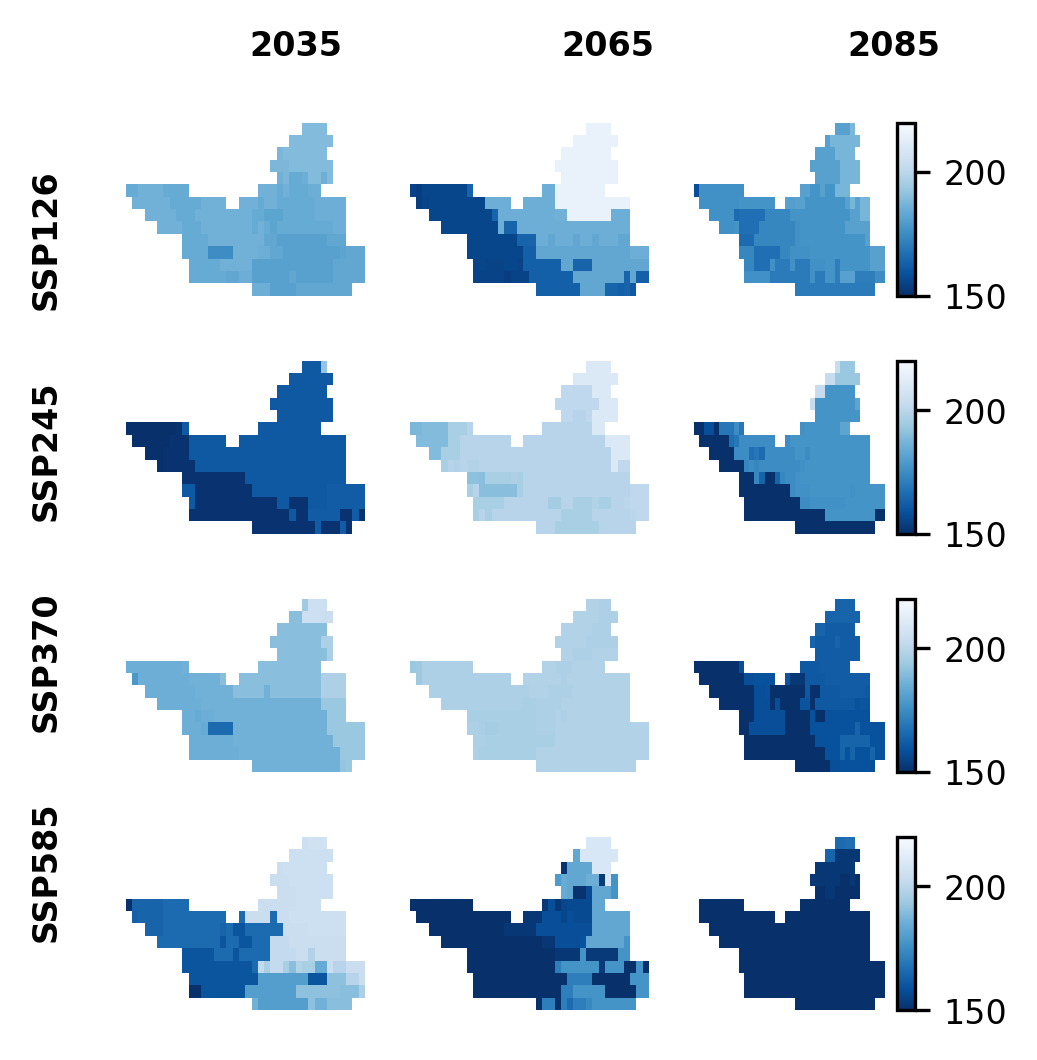

In [380]:
def plot_subplot(ax, data, vmin, vmax, add_colorbar=False):
    mesh = data.plot(x='lon', y='lat', vmin=vmin, vmax=vmax, add_colorbar=add_colorbar, cmap='Blues_r',
                     add_labels=False, xticks=None, yticks=None, ax=ax)
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
    for pos in ['right', 'top', 'bottom', 'left']:
        ax.spines[pos].set_visible(False)
    return mesh

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(3.8,3.5), dpi=300)

ssp_scenarios = [ssp126_spring, ssp245_spring, ssp370_spring, ssp585_spring]
time_indices = [20, 40, 70] # selecting the time indices for the year
row_titles = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
col_titles = ['2035', '2065', '2085']
vmin, vmax = 150, 220

# Plotting data
for i, (ssp, row_title) in enumerate(zip(ssp_scenarios, row_titles)):
    for j, idx in enumerate(time_indices):
        add_colorbar = (j == len(time_indices) - 1)  # Add colorbar to the last plot in each row
        mesh = plot_subplot(axes[i, j], ssp[idx], vmin, vmax, add_colorbar=False)
        
        if add_colorbar:
            cbar = plt.colorbar(mesh, ax=axes[i, j], orientation='vertical',aspect=10)
            cbar.ax.tick_params(labelsize=8)

    # Calculate vertical center for the row
    row_y_center = (axes[i, 0].get_position().y0 + axes[i, -1].get_position().y1) / 2
    # Set the vertical title using fig.text
    fig.text(0.02, row_y_center, row_title, va='center', ha='center', rotation='vertical', fontsize=8, fontweight='bold')

# Set column titles
for j, col_title in enumerate(col_titles):
    col_x_center = (axes[0, j].get_position().x0 + axes[-1, j].get_position().x1) / 2
    fig.text(col_x_center, 0.98, col_title, va='center', ha='center', fontsize=8, fontweight='bold')

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])  # Adjust layout to make room for titles
plt.savefig(f'{DATADIR}FSL_test.png')
plt.show()

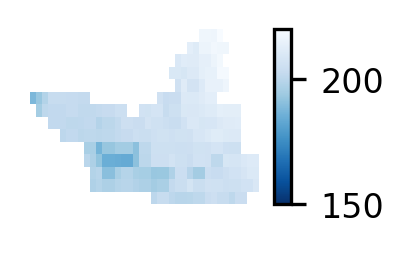

In [381]:
# Generate the reference plot with the same size as individual subplots
fig, ax = plt.subplots(figsize=(1.7,1),dpi=300)

# Plot the reference data
mesh = plot_subplot(ax, hist_ref_mean, vmin, vmax)

# Add color bar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical',aspect=10)
cbar.ax.tick_params(labelsize=8)

# Adjust layout
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])

# Save the reference plot
plt.savefig(f'{DATADIR}FSL_test-ref.png')

# Show the reference plot
plt.show()

# D. Aggregation to DataFrame

In [ ]:
hist_agg= spatial_agg(hist_spring)
df_hist= dataframe(hist_agg)

In [585]:
def dataframe(ds):
    df = ds.to_dataframe()
    df.index= df.index.to_datetimeindex()
    return df


In [88]:
#Aggregation the spatial values to one value

hist_agg= spatial_agg(hist_spring)
ssp126_agg = spatial_agg(ssp126_spring)
ssp245_agg = spatial_agg(ssp245_spring)
ssp375_agg = spatial_agg(ssp370_spring)
ssp585_agg = spatial_agg(ssp585_spring)



### To DataFrame

In [616]:
#from xarray to DataFrame
df_hist= dataframe(hist_agg)
df_ssp126= dataframe(ssp126_agg)
df_ssp245= dataframe(ssp245_agg)
df_ssp370=dataframe(ssp375_agg)
df_ssp585= dataframe(ssp585_agg)

#df_hist= df_hist.drop(['experiment', 'quantile', 'spatial_ref'], axis=1)
df_ssp126= df_ssp126.drop(['experiment', 'quantile', 'spatial_ref'], axis=1)
df_ssp245= df_ssp245.drop(['experiment', 'quantile', 'spatial_ref'], axis=1)
df_ssp370= df_ssp370.drop(['experiment', 'quantile', 'spatial_ref'], axis=1)
df_ssp585= df_ssp585.drop(['experiment', 'quantile', 'spatial_ref'], axis=1)

In [ ]:
#Renaming column names
df_ssp126.rename(columns={'csdi_6':'csdi_6_ssp126'}, inplace = True)
df_ssp245.rename(columns={'csdi_6':'csdi_6_ssp245'}, inplace = True)
df_ssp370.rename(columns={'csdi_6':'csdi_6_ssp370'}, inplace = True)
df_ssp585.rename(columns={'csdi_6':'csdi_6_ssp585'}, inplace = True)

In [ ]:
#Concanate to one DataFrame
result = pd.concat([df_ssp126,df_ssp245,df_ssp370,df_ssp585], axis=1, join='inner')
result.index= result.index.to_datetimeindex()


# E. Trend Analysis

In [31]:
#Original Mann Kendall test
mk.original_test(df_ssp585)

Mann_Kendall_Test(trend='decreasing', h=True, p=2.693631984129752e-09, z=-5.949256519471812, Tau=-0.43666210670314637, s=-1596.0, var_s=71878.0, slope=-0.8468522979169576, intercept=94.88615668453909)

In [97]:
#Modified Mann Kendal Test

mk.hamed_rao_modification_test(df_hist)

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='decreasing', h=True, p=0.004930100720946795, z=-2.8115657900617212, Tau=-0.30197444831591175, s=-260.0, var_s=8486.0, slope=-0.16725335793405666, intercept=8.768231634157223)

In [81]:
#Plotting with a trend line
y1= np.array(df_hist)
y_126 = np.array(df_ssp126)
y_245 = np.array(df_ssp245)
y_370 = np.array(df_ssp370)
y_585 = np.array(df_ssp585)

#years= np.arange(2015, 2101)
years= np.arange(2015, 2100) #Hydrological year
X= years.reshape(-1, 1)

#years2= np.arange(1980, 2015)
#years2= np.arange(1980, 2023)  #Observed
years2= np.arange(1980, 2022)#Hydrological year

X2= years2.reshape(-1, 1)

model_hist = LinearRegression()
model_hist.fit(X2, y1)

model_126 = LinearRegression()
model_126.fit(X, y_126)

model_245 = LinearRegression()
model_245.fit(X, y_245)

model_370 = LinearRegression()
model_370.fit(X, y_370)

model_585 = LinearRegression()
model_585.fit(X, y_585)



# Predict values based on the linear regression model

predicted_values_hist= model_hist.predict(X2)
predicted_values_126 = model_126.predict(X)
predicted_values_245 = model_245.predict(X)
predicted_values_370 = model_370.predict(X)
predicted_values_585 = model_585.predict(X)


C:\Users\cnakigud23\AppData\Local\Temp\ipykernel_16332\18054756.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,1)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


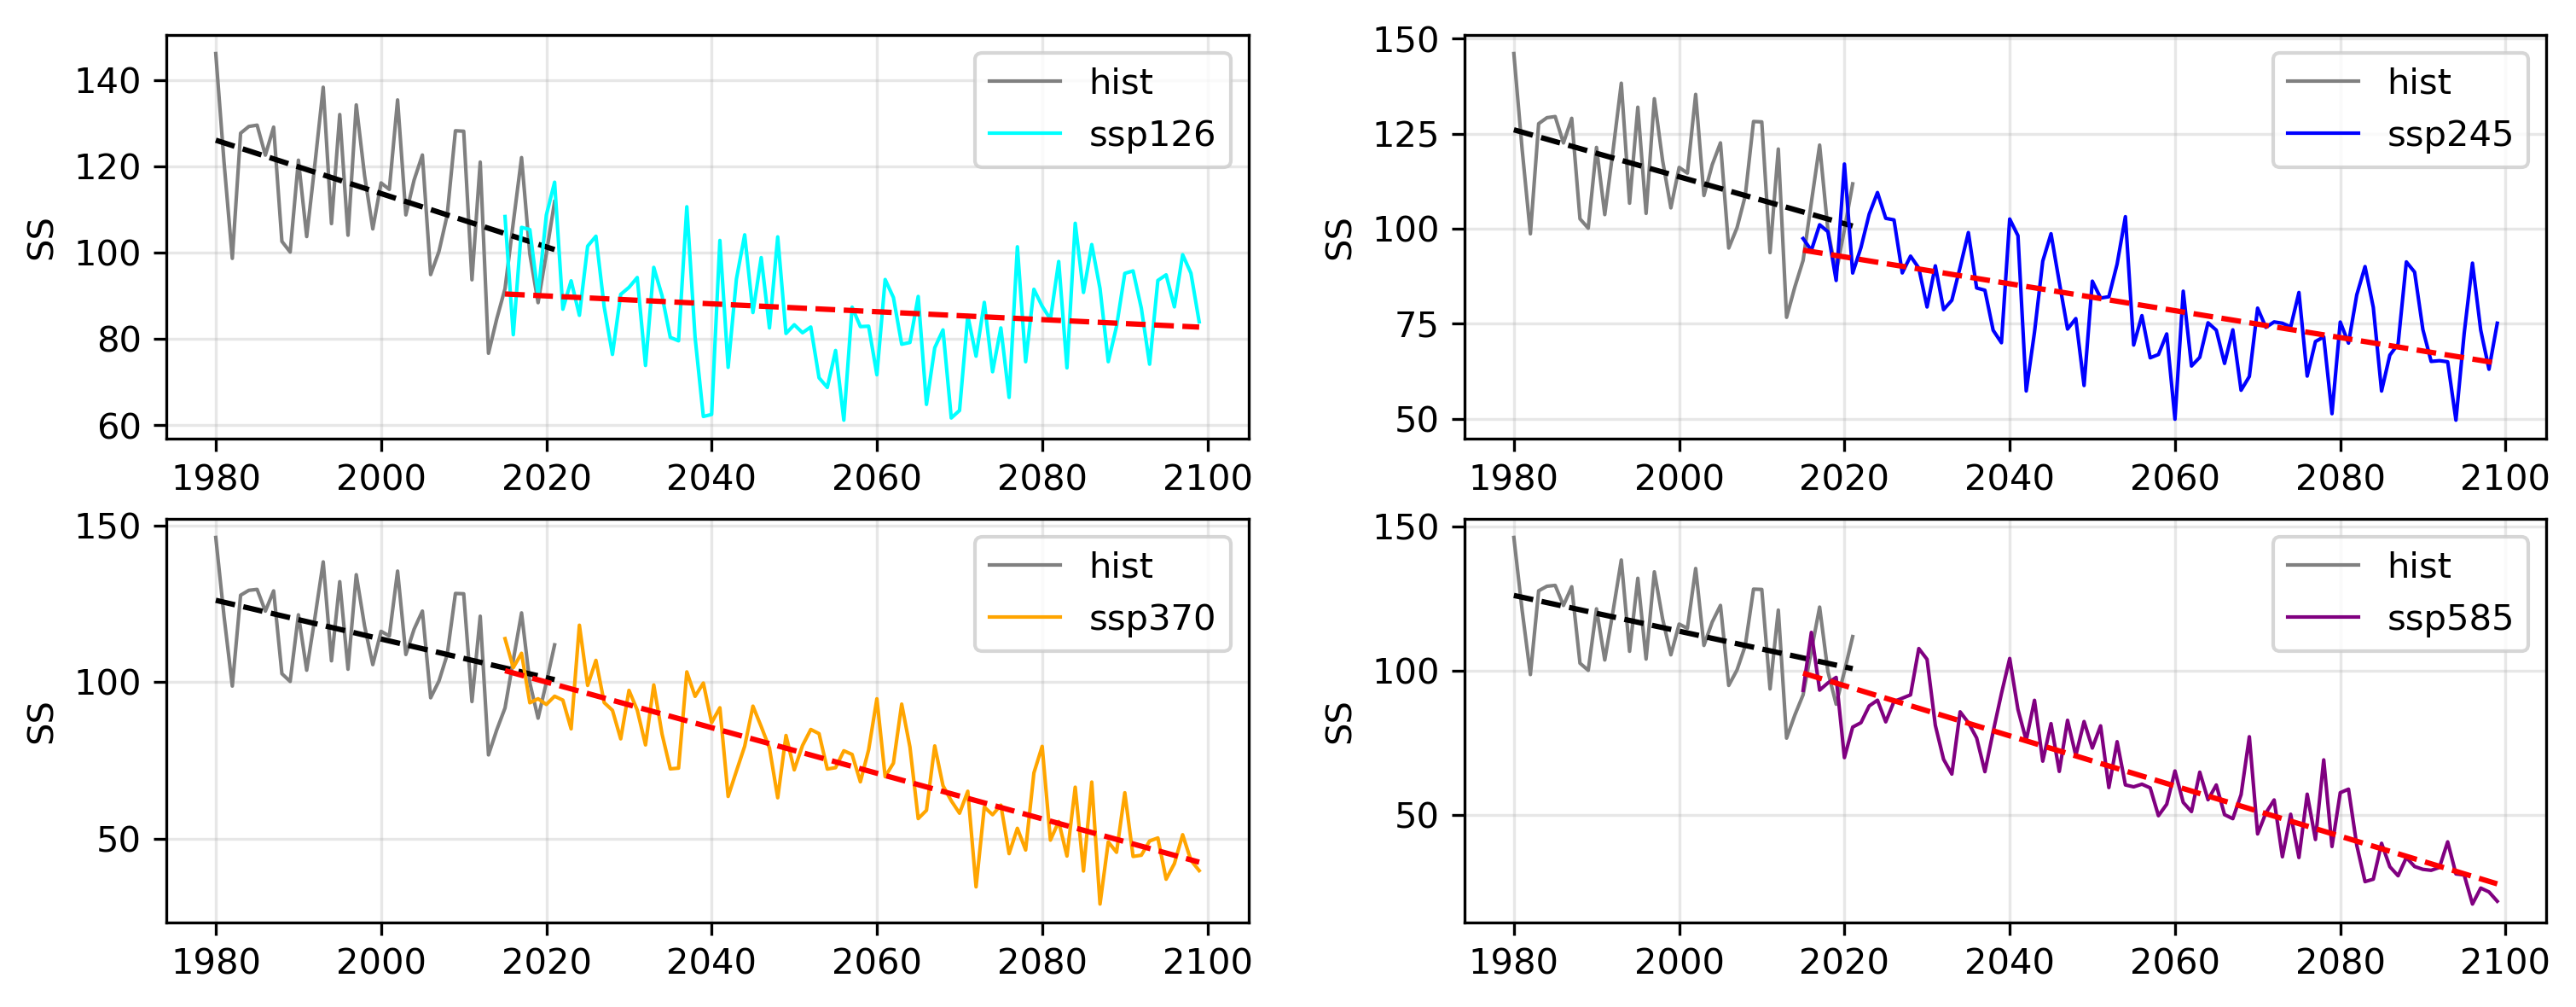

In [37]:
fig, ax= plt.subplots(figsize=(12, 4.5),dpi=300)
plt.subplot(2,2,1)
plt.plot(X2,y1, label = 'hist', color='grey', linewidth=1.0)
plt.plot(X2,predicted_values_hist, linestyle='--', color='k')
plt.plot(X, y_126, linestyle='-', label = 'ssp126', color='cyan',linewidth=1.0 )
plt.plot(X, predicted_values_126, linestyle='--', color='red')
plt.ylabel('SS')
plt.gca().grid(alpha=.3)
plt.legend(loc='upper right')


plt.subplot(2,2,2)
plt.plot(X2,y1, label = 'hist', color='grey', linewidth=1.0)
plt.plot(X2,predicted_values_hist, linestyle='--', color='k')
plt.plot(X, y_245,  linestyle='-', label = 'ssp245', color='b',linewidth=1.0 )
plt.plot(X, predicted_values_245, linestyle='--', color='red')
plt.ylabel('SS')
plt.gca().grid(alpha=.3)
plt.legend(loc='upper right')

plt.subplot(2,2,3)
plt.plot(X2,y1,label = 'hist', color='grey', linewidth=1.0)
plt.plot(X2,predicted_values_hist, linestyle='--', color='k')
plt.plot(X, y_370,  linestyle='-', label = 'ssp370', color='orange',linewidth=1.0 )
plt.plot(X, predicted_values_370, linestyle='--', color='red')
plt.ylabel('SS')
plt.gca().grid(alpha=.3)
plt.legend(loc='upper right')

plt.subplot(2,2,4)
plt.plot(X2,y1, label = 'hist', color='grey', linewidth=1.0)
plt.plot(X2,predicted_values_hist, linestyle='--', color='k')
plt.plot(X, y_585,  linestyle='-', label = 'ssp585', color='purple',linewidth=1.0 )
plt.plot(X, predicted_values_585, linestyle='--', color='red')
plt.ylabel('SS')
plt.gca().grid(alpha=.3)
plt.legend(loc='upper right')

# Add labels and legend
#plt.xlim(1980, 2100)
#plt.xlabel('year')
#plt.title(" Day of spring start")
ax.set_ylabel('Spring Start')

ax.grid(alpha=.3)
ax.legend()
# Show the plot
#plt.savefig(f'Day of Spring Start.png')
#plt.tight_layout()
plt.show()

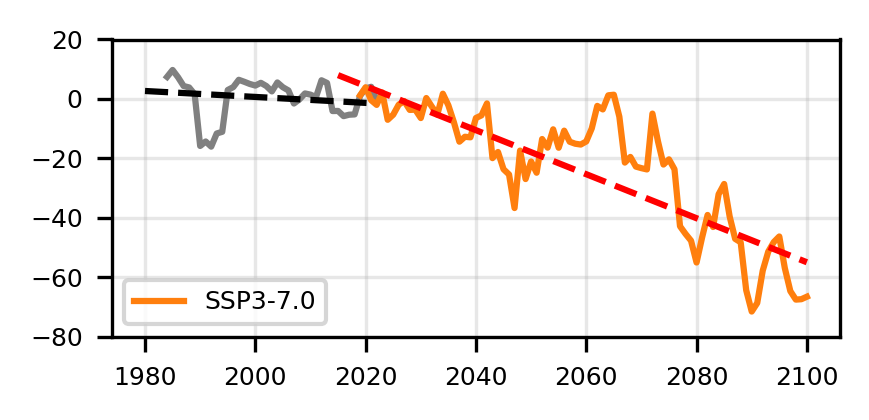

In [128]:
fig, ax = plt.subplots(figsize=(3.0, 1.5), dpi=300)
ax.plot(df_hist_advance.rolling(window=5).mean(),color='grey')
ax.plot(df_hist.index,predicted_values_hist1, linestyle='--', color='k',linewidth=1.5)


ax.plot(result_advance['freshet_start_ssp370'].rolling(window=5).mean(),color='tab:orange',linewidth=1.5,  label='SSP3-7.0')
ax.plot(result.index,predicted_values_3701, linestyle='--',color='red', linewidth=1.5)

#ax.set_ylabel('Spring_advance')

ax.xaxis.set_tick_params(labelsize=6)
ax.yaxis.set_tick_params(labelsize=6)

ax.set_ylim(-80,20)
ax.grid(alpha=.3)
ax.legend(fontsize=6, loc='lower left' )

plt.tight_layout()
plt.savefig(f'Day of Spring Start370.png')

plt.show()

# Standard Precipitation Index

In [ ]:
hist_pr_ref = hist_pr.sel(time = slice('1991-09-01', '2020-08-31'))

In [147]:
ssp126_spi6= SPI_3(hist_pr_ref, ssp126_pr)
ssp245_spi6= SPI_3(hist_pr_ref, ssp245_pr)
ssp370_spi6= SPI_3(hist_pr_ref, ssp370_pr)
ssp585_spi6= SPI_3(hist_pr_ref, ssp585_pr)

In [148]:
#= np.nan  #Change infinity to NaN
ssp126_spi6= ssp126_spi6.where(np.isinf(ssp126_spi6)== False)
ssp245_spi6= ssp245_spi6.where(np.isinf(ssp245_spi6)== False)
ssp370_spi6= ssp370_spi6.where(np.isinf(ssp370_spi6)== False)
ssp585_spi6= ssp585_spi6.where(np.isinf(ssp585_spi6)== False)

## References 

<font size ='3.2'>Bourgault, P., Huard, D., Smith, T.J., Aoun, A., Lavoie, J., Dupuis, E., ´ Alegre, R., Barnes, C., Beaupr´e, A., Biner, S., Caron, D., Ehbrecht, C., Keel, T., Labont´e, M.,
Lierhammer, L., Low, J., Quinn, J., Roy, P., Squire, D., 2023. xclim: xarray-based climate data analytics. J. Open Source Softw. 8, 8–11. https://doi.org/
10.21105/joss.05415.</font>

